# 🔬 NEXUS Stock AI — Phases 21, 22, 27, & 28
## SHAP Explainability, Model Serialization, & Standalone Inference Engine

**Objective:** Complete the productionization cycle for the NEXUS multi-modal XGBoost direction predictor:
1. **Phases 21 & 22 (SHAP Explainability):** Audit global and local feature impacts with `shap.TreeExplainer`, identifying the quantitative contribution of price vs. news features.
2. **Phase 27 (Model Artifact Serialization):** Save the trained Experiment C model into native JSON format (`xgb_direction.json`), along with strict feature schemas (`feature_schema.json`) and provenance metadata (`model_metadata.json`).
3. **Phase 28 (Standalone Inference Engine):** Verify the self-contained `NexusInferenceEngine` module on out-of-sample data, producing structured JSON payloads with directional probabilities and top driving factors.
4. **Artifact Backup:** Package all new model and source files into `nexus_data_backup.zip`.

### ⚙️ Step 1: Environment Setup & Data Loading

In [6]:
# Install required ML and explainability dependencies
%pip install -q shap xgboost scikit-learn matplotlib pyarrow

import os
import sys
import gc
import time
import json
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import shap

# Mount Google Drive if in Colab
try:
    from google.colab import drive
    print("Mounting Google Drive at /content/drive...")
    drive.mount("/content/drive")
    print("✓ Google Drive mounted successfully.")
except Exception as e:
    print(f"Drive mount note: {e}")

# Configure project paths
GDRIVE_BASE = "/content/drive/MyDrive/NEXUS_Stock_AI"
GDRIVE_DATA = os.path.join(GDRIVE_BASE, "data")
GDRIVE_MODELS = os.path.join(GDRIVE_BASE, "models")
LOCAL_DATA = "./data"
LOCAL_MODELS = "./models"

os.makedirs(LOCAL_MODELS, exist_ok=True)
if os.path.exists(GDRIVE_BASE):
    os.makedirs(GDRIVE_MODELS, exist_ok=True)

def resolve_path(filename):
    gdrive_p = os.path.join(GDRIVE_DATA, filename)
    local_p = os.path.join(LOCAL_DATA, filename)
    if os.path.exists(gdrive_p):
        return gdrive_p
    elif os.path.exists(local_p):
        return local_p
    return gdrive_p

DATASET_PATH = resolve_path("model_dataset_v1.parquet")
print(f"Dataset: {DATASET_PATH} (Exists: {os.path.exists(DATASET_PATH)})")

Mounting Google Drive at /content/drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted successfully.
Dataset: /content/drive/MyDrive/NEXUS_Stock_AI/data/model_dataset_v1.parquet (Exists: True)


### 📦 Step 2: Prepare Splits & Fit Production Model
Reconstruct the chronological split (Train 2018–2021, Val 2022, Test 2023) and train the multi-modal Experiment C model.

In [7]:
df = pd.read_parquet(DATASET_PATH)
df['date'] = pd.to_datetime(df['date']).dt.normalize()
df_filtered = df[df['date'] >= '2018-01-01'].sort_values(['date', 'stock_symbol']).reset_index(drop=True)

# Define Exact 23 Feature Schema in Strict Sequential Order
feature_schema = [
    'return_1d', 'return_3d', 'return_5d',
    'sma_5', 'sma_20', 'sma_50', 'ema_12', 'ema_26',
    'macd', 'macd_signal', 'rsi_14',
    'volatility_5d', 'volatility_20d',
    'volume_change_1d', 'volume_sma_20',
    'news_count', 'sentiment_mean', 'sentiment_std',
    'sentiment_min', 'sentiment_max',
    'positive_ratio', 'negative_ratio', 'neutral_ratio'
]

target_col = 'target'

# Chronological Split Masks
train_mask = (df_filtered['date'] >= '2018-01-01') & (df_filtered['date'] <= '2021-12-31')
val_mask   = (df_filtered['date'] >= '2022-01-01') & (df_filtered['date'] <= '2022-12-31')
test_mask  = (df_filtered['date'] >= '2023-01-01') & (df_filtered['date'] <= '2023-12-31')

train_df = df_filtered[train_mask].copy().reset_index(drop=True)
val_df   = df_filtered[val_mask].copy().reset_index(drop=True)
test_df  = df_filtered[test_mask].copy().reset_index(drop=True)

X_train, y_train = train_df[feature_schema], train_df[target_col].values
X_val, y_val     = val_df[feature_schema], val_df[target_col].values
X_test, y_test   = test_df[feature_schema], test_df[target_col].values

print(f"Train samples: {len(X_train):,} | Val samples: {len(X_val):,} | Test samples: {len(X_test):,}")

# Fit Production XGBoost Model
xgb_params = {
    'n_estimators': 300,
    'max_depth': 5,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'logloss',
    'early_stopping_rounds': 20,
    'random_state': 42,
    'tree_method': 'hist'
}

print("\nTraining multi-modal Experiment C model...")
model = xgb.XGBClassifier(**xgb_params)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f"✓ Trained model. Best iteration: {getattr(model, 'best_iteration', model.n_estimators)}")

# Out-of-sample metrics
from sklearn.metrics import roc_auc_score, f1_score
y_test_probs = model.predict_proba(X_test)[:, 1]
y_test_preds = (y_test_probs >= 0.5).astype(int)
test_auc = roc_auc_score(y_test, y_test_probs)
test_f1  = f1_score(y_test, y_test_preds)
print(f"✓ Test Set 2023 Results: ROC-AUC = {test_auc:.4f} | F1-Score = {test_f1:.4f}")

Train samples: 8,241 | Val samples: 1,757 | Test samples: 1,736

Training multi-modal Experiment C model...
✓ Trained model. Best iteration: 2
✓ Test Set 2023 Results: ROC-AUC = 0.5179 | F1-Score = 0.7130


### 🔍 Step 3: Phases 21 & 22 — SHAP Explainability Analysis
- **Global Impact:** Beeswarm and bar plots illustrating price vs. news feature rankings.
- **Local Impact:** Sample waterfall breakdown showing positive drivers (pushing UP) and negative drivers (pushing DOWN).

PHASES 21 & 22: SHAP GLOBAL & LOCAL EXPLAINABILITY


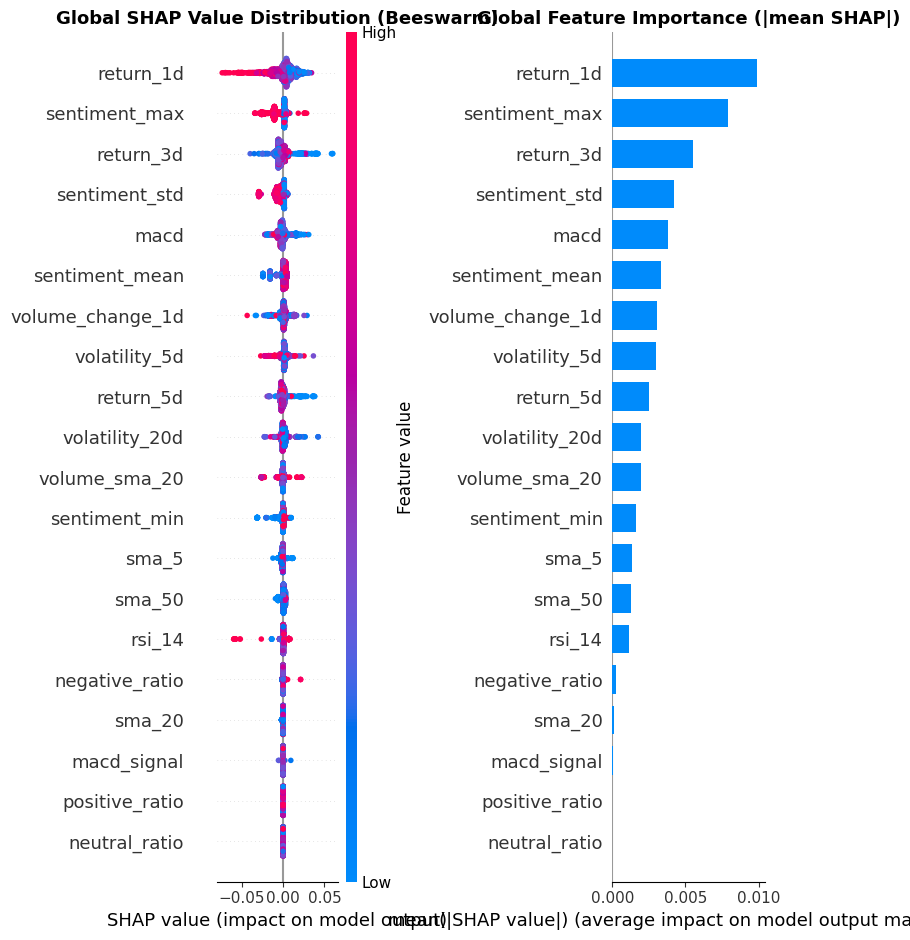

✓ Saved global SHAP summary plot: /content/drive/MyDrive/NEXUS_Stock_AI/models/shap_summary_plot.png


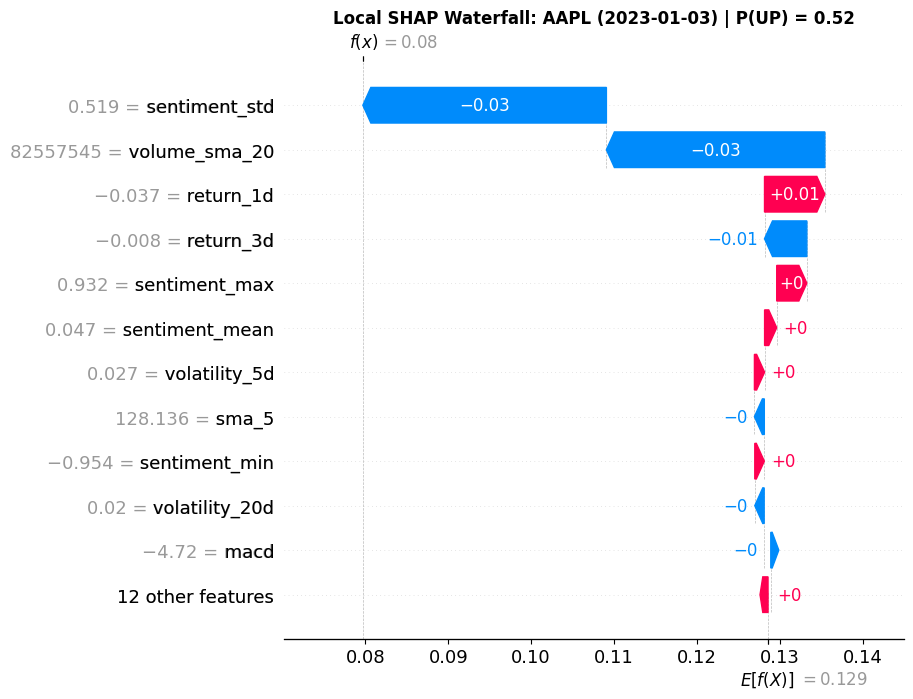

✓ Saved local SHAP sample explanation: /content/drive/MyDrive/NEXUS_Stock_AI/models/shap_sample_explanation.png


In [8]:
print("=" * 80)
print("PHASES 21 & 22: SHAP GLOBAL & LOCAL EXPLAINABILITY")
print("=" * 80)

explainer = shap.TreeExplainer(model)
shap_explanation = explainer(X_test)

# 1. Global Summary Plots (Beeswarm and Bar Chart)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

plt.sca(ax1)
shap.summary_plot(shap_explanation.values, X_test, feature_names=feature_schema, plot_type="dot", show=False)
ax1.set_title("Global SHAP Value Distribution (Beeswarm)", fontsize=13, fontweight='bold')

plt.sca(ax2)
shap.summary_plot(shap_explanation.values, X_test, feature_names=feature_schema, plot_type="bar", show=False)
ax2.set_title("Global Feature Importance (|mean SHAP|)", fontsize=13, fontweight='bold')

plt.tight_layout()
summary_plot_path = os.path.join(GDRIVE_MODELS, "shap_summary_plot.png") if os.path.exists(GDRIVE_MODELS) else "./models/shap_summary_plot.png"
plt.savefig(summary_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"✓ Saved global SHAP summary plot: {summary_plot_path}")

# 2. Local Sample Waterfall Breakdown
sample_idx = 0
sample_row = test_df.iloc[sample_idx]
sample_ticker = sample_row['stock_symbol']
sample_date = sample_row['date'].strftime('%Y-%m-%d')
sample_prob = y_test_probs[sample_idx]

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation[sample_idx], max_display=12, show=False)
plt.title(f"Local SHAP Waterfall: {sample_ticker} ({sample_date}) | P(UP) = {sample_prob:.2f}", fontsize=12, fontweight='bold')

sample_plot_path = os.path.join(GDRIVE_MODELS, "shap_sample_explanation.png") if os.path.exists(GDRIVE_MODELS) else "./models/shap_sample_explanation.png"
plt.savefig(sample_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"✓ Saved local SHAP sample explanation: {sample_plot_path}")

### 💾 Step 4: Phase 27 — Model Artifact Serialization
Persist native model JSON, exact schema specification, and model metadata to Drive and local storage.

In [9]:
print("=" * 80)
print("PHASE 27: MODEL ARTIFACT SERIALIZATION")
print("=" * 80)

target_models_dir = GDRIVE_MODELS if os.path.exists(GDRIVE_MODELS) else LOCAL_MODELS

# 1. Save Native XGBoost Model JSON
model_out_path = os.path.join(target_models_dir, "xgb_direction.json")
local_model_path = os.path.join(LOCAL_MODELS, "xgb_direction.json")
model.save_model(model_out_path)
if os.path.abspath(model_out_path) != os.path.abspath(local_model_path):
    shutil.copy2(model_out_path, local_model_path)
print(f"✓ Serialized Model: {model_out_path} ({os.path.getsize(model_out_path)/(1024):.1f} KB)")

# 2. Save Feature Schema JSON
schema_out_path = os.path.join(target_models_dir, "feature_schema.json")
local_schema_path = os.path.join(LOCAL_MODELS, "feature_schema.json")
schema_payload = {
    "feature_count": len(feature_schema),
    "features": feature_schema
}
with open(schema_out_path, "w", encoding="utf-8") as f:
    json.dump(schema_payload, f, indent=2)
if os.path.abspath(schema_out_path) != os.path.abspath(local_schema_path):
    shutil.copy2(schema_out_path, local_schema_path)
print(f"✓ Serialized Feature Schema: {schema_out_path}")

# 3. Save Model Metadata JSON
metadata_out_path = os.path.join(target_models_dir, "model_metadata.json")
local_metadata_path = os.path.join(LOCAL_MODELS, "model_metadata.json")
metadata_payload = {
    "model_name": "NEXUS_XGBoost_Direction_Classifier",
    "model_version": "v1.0.0",
    "training_window": {"start": "2018-01-01", "end": "2021-12-31"},
    "validation_window": {"start": "2022-01-01", "end": "2022-12-31"},
    "test_window": {"start": "2023-01-01", "end": "2023-12-31"},
    "out_of_sample_metrics": {
        "roc_auc": round(float(test_auc), 4),
        "f1_score": round(float(test_f1), 4)
    },
    "tickers": sorted(list(df_filtered['stock_symbol'].unique())),
    "hyperparameters": xgb_params
}
with open(metadata_out_path, "w", encoding="utf-8") as f:
    json.dump(metadata_payload, f, indent=2)
if os.path.abspath(metadata_out_path) != os.path.abspath(local_metadata_path):
    shutil.copy2(metadata_out_path, local_metadata_path)
print(f"✓ Serialized Model Metadata: {metadata_out_path}")

PHASE 27: MODEL ARTIFACT SERIALIZATION
✓ Serialized Model: /content/drive/MyDrive/NEXUS_Stock_AI/models/xgb_direction.json (82.9 KB)
✓ Serialized Feature Schema: /content/drive/MyDrive/NEXUS_Stock_AI/models/feature_schema.json
✓ Serialized Model Metadata: /content/drive/MyDrive/NEXUS_Stock_AI/models/model_metadata.json


### ⚡ Step 5: Phase 28 — Standalone Inference Module Verification
Import and verify `NexusInferenceEngine` from `src.inference.predict` using a sample from the 2023 test set.

In [10]:
print("=" * 80)
print("PHASE 28: STANDALONE INFERENCE MODULE VERIFICATION")
print("=" * 80)

# 1. Ensure src/inference package exists directly in Colab working directory
os.makedirs("src/inference", exist_ok=True)

with open("src/inference/__init__.py", "w", encoding="utf-8") as f:
    f.write("from .predict import NexusInferenceEngine\n__all__ = [\"NexusInferenceEngine\"]\n")

predict_source = '#!/usr/bin/env python3\n"""\nNEXUS Stock AI — Standalone Inference Engine (Phase 28)\nProvides production-ready inference and local factor explainability for next-day direction.\n"""\n\nimport os\nimport json\nfrom typing import List, Dict, Any, Union\nimport numpy as np\nimport pandas as pd\nimport xgboost as xgb\n\n\nclass NexusInferenceEngine:\n    """\n    Production inference engine for NEXUS Stock AI.\n    Loads native XGBoost JSON artifacts and runs validated, explainable predictions.\n    """\n\n    def __init__(\n        self,\n        model_path: str = "./models/xgb_direction.json",\n        schema_path: str = "./models/feature_schema.json"\n    ):\n        if not os.path.exists(model_path):\n            alt_path = os.path.join("/content/drive/MyDrive/NEXUS_Stock_AI/models", os.path.basename(model_path))\n            if os.path.exists(alt_path):\n                model_path = alt_path\n            else:\n                raise FileNotFoundError(f"Model file not found at: {model_path} or {alt_path}")\n\n        if not os.path.exists(schema_path):\n            alt_schema = os.path.join("/content/drive/MyDrive/NEXUS_Stock_AI/models", os.path.basename(schema_path))\n            if os.path.exists(alt_schema):\n                schema_path = alt_schema\n            else:\n                raise FileNotFoundError(f"Schema file not found at: {schema_path} or {alt_schema}")\n\n        with open(schema_path, "r", encoding="utf-8") as f:\n            schema_data = json.load(f)\n            if isinstance(schema_data, dict) and "features" in schema_data:\n                self.feature_names = schema_data["features"]\n            elif isinstance(schema_data, list):\n                self.feature_names = schema_data\n            else:\n                raise ValueError("Unexpected schema format. Expected list or dict with \'features\' key.")\n\n        self.model = xgb.XGBClassifier()\n        self.model.load_model(model_path)\n        self.booster = self.model.get_booster()\n        self.model_path = model_path\n        self.schema_path = schema_path\n\n    def predict(\n        self,\n        input_features: pd.DataFrame,\n        top_k_factors: int = 3\n    ) -> List[Dict[str, Any]]:\n        if not isinstance(input_features, pd.DataFrame):\n            raise TypeError("input_features must be a pandas DataFrame.")\n\n        missing_cols = [c for c in self.feature_names if c not in input_features.columns]\n        if missing_cols:\n            raise ValueError(f"Input features missing required schema columns ({len(missing_cols)}): {missing_cols}")\n\n        X = input_features[self.feature_names].copy()\n\n        if X.isna().any().any():\n            nan_cols = X.columns[X.isna().any()].tolist()\n            raise ValueError(f"Input features contain NaN values in columns: {nan_cols}")\n\n        probs = self.model.predict_proba(X)\n        preds = (probs[:, 1] >= 0.5).astype(int)\n\n        dmatrix = xgb.DMatrix(X, feature_names=self.feature_names)\n        contribs = self.booster.predict(dmatrix, pred_contribs=True)\n\n        results = []\n        for i in range(len(input_features)):\n            row_raw = input_features.iloc[i]\n            ticker = str(row_raw.get("stock_symbol", row_raw.get("ticker", "UNKNOWN")))\n            \n            trade_date_val = row_raw.get("date", row_raw.get("trade_date", "UNKNOWN"))\n            if isinstance(trade_date_val, (pd.Timestamp, np.datetime64)):\n                trade_date = pd.to_datetime(trade_date_val).strftime("%Y-%m-%d")\n            else:\n                trade_date = str(trade_date_val)\n\n            up_prob = float(round(probs[i, 1], 4))\n            down_prob = float(round(probs[i, 0], 4))\n            prediction_label = "UP" if preds[i] == 1 else "DOWN"\n\n            row_contribs = contribs[i, :-1]\n            factor_list = []\n            for feat_name, impact_val in zip(self.feature_names, row_contribs):\n                factor_list.append({\n                    "feature": feat_name,\n                    "direction": "UP" if impact_val > 0 else "DOWN",\n                    "impact": float(round(abs(impact_val), 4))\n                })\n\n            factor_list.sort(key=lambda x: x["impact"], reverse=True)\n            top_factors = factor_list[:top_k_factors]\n\n            results.append({\n                "ticker": ticker,\n                "trade_date": trade_date,\n                "prediction": prediction_label,\n                "up_probability": up_prob,\n                "down_probability": down_prob,\n                "top_factors": top_factors\n            })\n\n        return results\n'

with open("src/inference/predict.py", "w", encoding="utf-8") as f:
    f.write(predict_source)

# Mirror to Google Drive if accessible
if os.path.exists(GDRIVE_BASE):
    os.makedirs(os.path.join(GDRIVE_BASE, "src", "inference"), exist_ok=True)
    shutil.copy2("src/inference/predict.py", os.path.join(GDRIVE_BASE, "src", "inference", "predict.py"))
    shutil.copy2("src/inference/__init__.py", os.path.join(GDRIVE_BASE, "src", "inference", "__init__.py"))

# 2. Add working directory to Python path
if "." not in sys.path:
    sys.path.insert(0, ".")

from src.inference.predict import NexusInferenceEngine

# 3. Instantiate engine using serialized artifacts (with Drive fallback)
active_model = local_model_path if os.path.exists(local_model_path) else model_out_path
active_schema = local_schema_path if os.path.exists(local_schema_path) else schema_out_path

engine = NexusInferenceEngine(
    model_path=active_model,
    schema_path=active_schema
)

# 4. Select 2 representative rows from the 2023 test set
sample_input = test_df.head(2).copy()
predictions = engine.predict(sample_input, top_k_factors=3)

print("✓ Executed standalone inference engine:")
print(json.dumps(predictions, indent=2))


PHASE 28: STANDALONE INFERENCE MODULE VERIFICATION
✓ Executed standalone inference engine:
[
  {
    "ticker": "AAPL",
    "trade_date": "2023-01-03",
    "prediction": "UP",
    "up_probability": 0.5199000239372253,
    "down_probability": 0.48010000586509705,
    "top_factors": [
      {
        "feature": "return_1d",
        "direction": "UP",
        "impact": 0.12680000066757202
      },
      {
        "feature": "sentiment_max",
        "direction": "DOWN",
        "impact": 0.10279999673366547
      },
      {
        "feature": "sentiment_std",
        "direction": "DOWN",
        "impact": 0.051600001752376556
      }
    ]
  },
  {
    "ticker": "AMD",
    "trade_date": "2023-01-03",
    "prediction": "UP",
    "up_probability": 0.534600019454956,
    "down_probability": 0.46540001034736633,
    "top_factors": [
      {
        "feature": "sentiment_max",
        "direction": "DOWN",
        "impact": 0.0957999974489212
      },
      {
        "feature": "return_1d",
     

### 📦 Step 6: Backup Refresh
Update `nexus_data_backup.zip` to package the new `./models/` and `./src/` directories.

In [11]:
print("=" * 80)
print("REFRESHING BACKUP ARCHIVE")
print("=" * 80)

target_zip = "/content/nexus_data_backup.zip" if os.path.exists("/content") else "./nexus_data_backup.zip"
print(f"Updating: {target_zip}...")

with zipfile.ZipFile(target_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for folder in ["./data", "./models", "./src"]:
        if os.path.exists(folder):
            for root, _, files in os.walk(folder):
                for file in files:
                    if not file.endswith(".pyc") and "__pycache__" not in root:
                        fpath = os.path.join(root, file)
                        arcname = os.path.relpath(fpath, ".")
                        zipf.write(fpath, arcname)

zip_size = os.path.getsize(target_zip) / (1024 * 1024)
print(f"✓ Backup archive successfully refreshed ({zip_size:.2f} MB)")
print("=" * 80)
print("🎉 PHASES 21, 22, 27, & 28 COMPLETE & VERIFIED!")

REFRESHING BACKUP ARCHIVE
Updating: /content/nexus_data_backup.zip...
✓ Backup archive successfully refreshed (276.06 MB)
🎉 PHASES 21, 22, 27, & 28 COMPLETE & VERIFIED!
